# 05 – Model Monitoring

**Project:** AI-Powered Project Planning & Risk Forecasting Platform

Machine learning models degrade over time due to:

- changing project environments
- new types of projects
- evolving risk patterns
- data distribution shifts

This notebook demonstrates **basic model monitoring techniques** used in production ML systems.

Monitoring focuses on:

• prediction accuracy  
• forecast error  
• model confidence  
• potential data drift  

These monitoring metrics help teams detect when models may need **retraining or recalibration**.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Monitoring Dataset

In this notebook we analyze the **risk monitoring dataset**, which captures information about model predictions and their real-world outcomes.

This dataset includes variables such as:

- predicted project risk level
- actual observed risk level
- forecast error metrics
- model drift indicators

Monitoring this information is critical for evaluating whether the deployed model continues to perform reliably over time.

In production systems, model monitoring helps detect situations where model predictions become less accurate due to changing data patterns.

In [2]:
monitoring_df = pd.read_csv("../data/risk_monitoring_snapshot.csv")

monitoring_df.head()

,Snapshot_Month,Project_ID,Portfolio_Segment,Model_Version,Predicted_Risk_Level,Actual_Risk_Level,Prediction_Confidence,P80_Forecast_Days,Actual_Completion_Days,Absolute_Forecast_Error_Days,Drift_Score,Alerts_Open
0,2025-07-01,P013,Industrial,v1-advisory-multimodel,Low,Low,0.795,314,308,6,0.321,0
1,2025-07-01,P034,Public Sector,v1-advisory-multimodel,Low,Low,0.705,298,260,38,0.407,0
2,2025-07-01,P064,Energy,v1-advisory-multimodel,Low,Low,0.533,293,288,5,0.412,0
3,2025-07-01,P066,Infrastructure,v1-advisory-multimodel,Low,Low,0.686,289,274,15,0.358,0
4,2025-07-01,P069,Industrial,v1-advisory-multimodel,Low,Low,0.637,260,249,11,0.467,0


## Monitoring Dataset Description

The monitoring dataset (`risk_monitoring_snapshot.csv`) represents new project observations collected after the model was deployed.

This dataset simulates incoming project data in a production environment and is used to evaluate whether the model continues to perform reliably over time.

It enables monitoring of:
- prediction accuracy
- changes in the distribution of predicted risk levels
- forecast errors
- potential data drift

By analyzing this dataset, we can assess model stability and detect early signs of performance degradation.

## Dataset Overview

Before performing monitoring analysis, we inspect the structure of the dataset.

This helps confirm:

- the number of monitoring observations
- the available monitoring variables
- whether the dataset is suitable for evaluating model performance

Understanding the dataset structure is an important first step before computing performance metrics.

In [3]:
print("Rows:", monitoring_df.shape[0])
print("Columns:", monitoring_df.shape[1])

Rows: 270
Columns: 12


## Prediction Accuracy

A basic and important monitoring metric is **prediction accuracy**.

This measures how often the model’s predicted risk label matches the actual observed risk label.

Accuracy provides a high-level view of model performance and helps answer the question:

**Is the model still making reliable classifications?**

Although accuracy alone is not sufficient to judge a production model, it is a useful first indicator of overall model quality.

In [4]:
accuracy = (
    monitoring_df["Predicted_Risk_Level"]
    ==
    monitoring_df["Actual_Risk_Level"]
).mean()

print("Prediction Accuracy:", round(accuracy*100,2), "%")

Prediction Accuracy: 77.41 %


### Prediction Accuracy Calculation:

In this example, the model achieves **77.41% accuracy**, meaning that about **77% of risk levels were predicted correctly**.

## Risk Prediction Distribution

In addition to overall accuracy, it is useful to inspect the distribution of predicted risk levels.

This helps us understand whether the model tends to favor certain classes, such as:

- Low risk
- Medium risk
- High risk

Monitoring prediction distributions can reveal whether the model is becoming biased toward one class or whether class output patterns are changing over time.

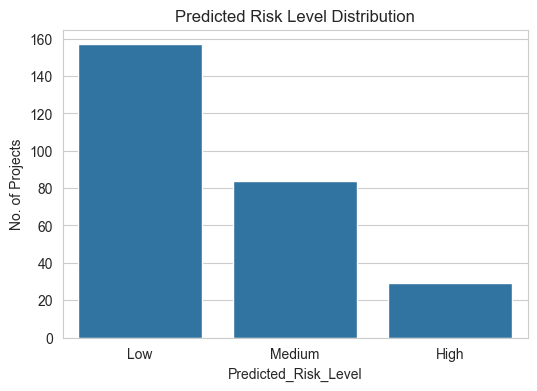

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Predicted_Risk_Level",
    data=monitoring_df,
    order=["Low","Medium","High"]
)

plt.title("Predicted Risk Level Distribution")
plt.xlabel("Predicted_Risk_Level")
plt.ylabel("No. of Projects")

plt.show()

### Predicted Risk Level Distribution

- This chart visualizes the **distribution of predicted project risk levels** generated by the trained model.
- The **x-axis** shows the predicted risk categories: **Low, Medium, and High**.
- The **y-axis** represents the **number of projects** assigned to each predicted risk level.
- A **count plot** is used to show how frequently each risk category appears in the predictions.
- The `order=["Low","Medium","High"]` parameter ensures that the risk levels appear in a **logical progression from low to high risk**.
- This visualization helps evaluate how the model distributes predictions across different risk categories.
- In this example, most projects are predicted as **Low risk**, followed by **Medium risk**, while **High risk** predictions occur less frequently.

## Actual Risk Distribution

We also inspect the distribution of actual observed risk levels.

Comparing predicted and actual class distributions helps determine whether the model output is aligned with the real project environment.

If the actual distribution changes substantially while the predicted distribution remains stable, this may indicate performance drift or changes in the underlying project population.

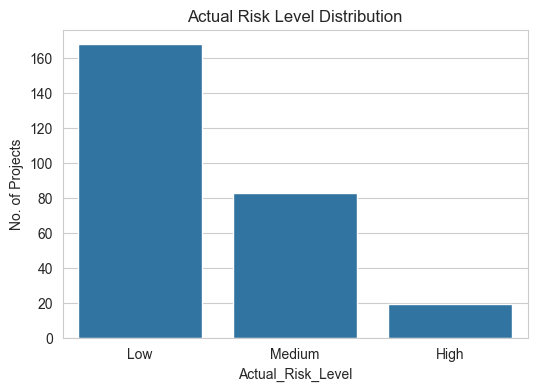

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Actual_Risk_Level",
    data=monitoring_df,
    order=["Low","Medium","High"]
)

plt.title("Actual Risk Level Distribution")
plt.xlabel("Actual_Risk_Level")
plt.ylabel("No. of Projects")

plt.show()

### Actual Risk Level Distribution

- This chart shows the **distribution of actual project risk levels** observed in the monitoring dataset.
- The **x-axis** displays the true risk categories: **Low, Medium, and High**.
- The **y-axis** represents the **number of projects** that fall into each actual risk category.
- The visualization provides insight into the **true risk profile of the project portfolio**.
- Most projects fall into the **Low risk category**, followed by **Medium risk**, while **High risk projects are relatively rare**.
- Understanding this distribution helps evaluate whether the **model predictions align with the real risk patterns** present in the data.

## Forecast Error Analysis

Monitoring is not only about classification quality. It is also important to track forecast reliability.

The variable `Absolute_Forecast_Error_Days` measures the gap between forecasted and actual completion time.

This metric helps answer:

**How close are the model-supported schedule forecasts to real project outcomes?**

Large forecast errors may indicate that the forecasting logic, assumptions, or data inputs need review.

In [10]:
monitoring_df["Absolute_Forecast_Error_Days"].describe()

count    270.000000
mean      15.877778
std       14.089328
min        0.000000
25%        7.000000
50%       11.000000
75%       19.000000
max       69.000000
Name: Absolute_Forecast_Error_Days, dtype: float64

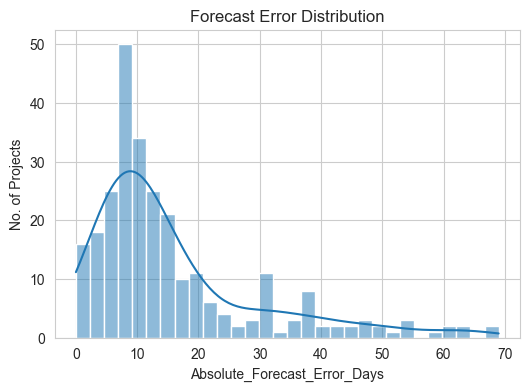

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(
    monitoring_df["Absolute_Forecast_Error_Days"],
    bins=30,
    kde=True
)

plt.title("Forecast Error Distribution")
plt.xlabel("Absolute_Forecast_Error_Days")
plt.ylabel("No. of Projects")

plt.show()

### Forecast Error Distribution

- This chart shows the **distribution of forecast errors** in the project completion predictions.
- The **x-axis** represents **Absolute_Forecast_Error_Days**, which measures the difference between the **predicted completion time** and the **actual completion time**.
- The **y-axis** represents the **number of projects** whose forecast error falls within each error range.
- Most projects have **small forecast errors**, indicating that the model's completion time predictions are often close to the actual outcomes.
- A smaller number of projects show **larger forecast errors**, which may indicate cases where project conditions differed significantly from the model's expectations.
- Analyzing this distribution helps evaluate the **reliability of the forecasting component** and identify situations where predictions may require improvement.

## Model Confidence Monitoring

Prediction confidence is another useful signal for monitoring model health.

A model may still produce predictions even when it is uncertain. Tracking confidence scores helps identify whether the model is becoming less certain over time.

Low confidence may suggest:

- ambiguous inputs
- changing project patterns
- weakening predictive reliability

Confidence monitoring is therefore valuable as an early warning signal.

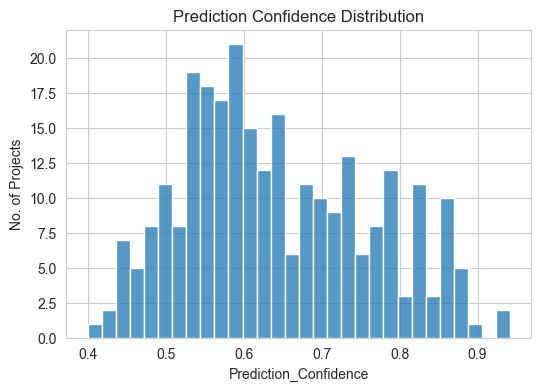

In [15]:
plt.figure(figsize=(6,4))

sns.histplot(
    monitoring_df["Prediction_Confidence"],
    bins=30
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Prediction_Confidence")
plt.ylabel("No. of Projects")

plt.show()

### Prediction Confidence Distribution

- This chart shows the **distribution of the model’s prediction confidence scores**.
- The **x-axis** represents **Prediction Confidence**, indicating how certain the model is about each predicted risk level.
- The **y-axis** represents the **number of projects** whose confidence scores fall within each confidence range.
- Higher confidence values indicate that the model is **more certain about its predictions**, while lower values indicate **greater uncertainty**.
- Most predictions cluster around **moderate to high confidence levels**, suggesting that the model is generally confident in its risk assessments.
- Monitoring prediction confidence helps detect situations where the model may become **less certain about its predictions**, which can signal potential changes in project patterns or model performance.

## Data Drift Detection

A production model can degrade when new data begins to differ from the data it was trained on.

This phenomenon is known as **data drift**.

The `Drift_Score` variable provides an indicator of how much the current data distribution may have shifted relative to the training or reference distribution.

Monitoring drift is important because even a previously strong model can become unreliable if the environment changes.

In [16]:
monitoring_df["Drift_Score"].describe()

count    270.000000
mean       0.383348
std        0.078678
min        0.202000
25%        0.326000
50%        0.382000
75%        0.431000
max        0.707000
Name: Drift_Score, dtype: float64

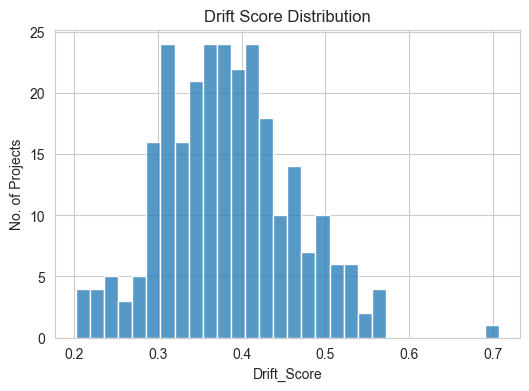

In [18]:
plt.figure(figsize=(6,4))

sns.histplot(
    monitoring_df["Drift_Score"],
    bins=30
)

plt.title("Drift Score Distribution")
plt.xlabel("Drift_Score")
plt.ylabel("No. of Projects")


plt.show()

### Drift Score Distribution

- This chart shows the **distribution of drift scores** across the monitoring dataset.
- The **x-axis** represents the **Drift_Score**, which indicates how much the current project data differs from the data used to train the model.
- The **y-axis** represents the **number of projects** whose drift scores fall within each drift range.
- Lower drift scores suggest that the **current data remains similar to the training data**, indicating stable model conditions.
- Higher drift scores may indicate **changes in project characteristics or data patterns**, which could impact model reliability.
- Monitoring the drift score distribution helps identify **potential data drift**, signaling when the model may require review or retraining.

## Monitoring Alerts

In operational systems, monitoring metrics are often linked to alerting rules.

Alerts help flag conditions that may require investigation, such as:

- unusually high forecast error
- elevated drift scores
- low confidence predictions
- repeated model disagreements with actual outcomes

This section evaluates alert-related metrics to understand how frequently warning conditions occur in the monitoring snapshot.

In [19]:
high_drift_threshold = 0.55

drift_alert_rate = (
    monitoring_df["Drift_Score"] > high_drift_threshold
).mean()

print("High Drift Alert Rate:", round(drift_alert_rate*100,2), "%")

High Drift Alert Rate: 2.22 %


### High Drift Alert Rate

- A **drift threshold (0.55)** is defined to identify unusually high drift scores.
- Projects with a **Drift_Score above the threshold** are considered potential drift alerts.
- The **drift alert rate** measures the **percentage of projects experiencing high data drift**.
- In this example, **2.22% of projects exceed the drift threshold**, indicating limited data drift in the monitoring dataset.

In [23]:
# calculate total alerts
open_alerts = monitoring_df["Alerts_Open"].sum()

# create a new column containing the total alerts for all rows
monitoring_df["Total_Monitoring_Alerts"] = open_alerts

# display result
print("Total Monitoring Alerts:", open_alerts)

monitoring_df.head()

Total Monitoring Alerts: 10


,Snapshot_Month,Project_ID,Portfolio_Segment,Model_Version,Predicted_Risk_Level,Actual_Risk_Level,Prediction_Confidence,P80_Forecast_Days,Actual_Completion_Days,Absolute_Forecast_Error_Days,Drift_Score,Alerts_Open,Total_Monitoring_Alerts
0,2025-07-01,P013,Industrial,v1-advisory-multimodel,Low,Low,0.795,314,308,6,0.321,0,10
1,2025-07-01,P034,Public Sector,v1-advisory-multimodel,Low,Low,0.705,298,260,38,0.407,0,10
2,2025-07-01,P064,Energy,v1-advisory-multimodel,Low,Low,0.533,293,288,5,0.412,0,10
3,2025-07-01,P066,Infrastructure,v1-advisory-multimodel,Low,Low,0.686,289,274,15,0.358,0,10
4,2025-07-01,P069,Industrial,v1-advisory-multimodel,Low,Low,0.637,260,249,11,0.467,0,10


### Total Monitoring Alerts

- This step calculates the **total number of monitoring alerts across the entire monitoring dataset**, not the value for that specific row. If the dataset contains 10 alerts in total, then:
open_alerts = 10
- The **`Alerts_Open`** column indicates whether an alert was triggered for each project.
- Summing this column provides the **total number of alerts detected across all monitored projects**.
- The result is stored as **`Total_Monitoring_Alerts`** and added as a new column in the dataset.
- This value represents an **aggregated monitoring metric**, so the same total is displayed for each row.
- In this example, **10 monitoring alerts** were detected across the monitored projects.

## Monitoring Dashboard Metrics

To support operational monitoring, the platform can summarize key indicators into dashboard-ready metrics.

Key metrics tracked in the monitoring system:

• prediction accuracy  
• average forecast error  
• prediction confidence  
• drift score  
• alert frequency  

These metrics allow teams to monitor model health and ensure predictions remain reliable over time.

## Monitoring Insights

The monitoring results provide several important insights into the health of the deployed model.

Monitoring metrics help detect when model performance may begin to degrade. In particular, they allow the system to:

- detect when **prediction accuracy begins to decline**
- track whether **forecast errors are increasing over time**
- identify potential **data drift in new project inputs**
- observe changes in **model confidence levels**

These signals help determine whether corrective actions may be needed, such as:

- retraining the model on updated data
- recalibrating prediction thresholds
- investigating changes in project characteristics

The monitoring system therefore plays an important role in maintaining the reliability of the AI-powered planning platform.

In the full platform architecture, these monitoring signals feed into a **live monitoring dashboard**, allowing project managers and engineers to continuously evaluate model reliability and forecast performance over time.

## Monitoring Strategy Summary

In a production environment, monitoring metrics would be computed
periodically as new project outcomes become available.

These monitoring signals help detect potential model degradation
and changes in project data distributions.

If monitoring alerts exceed predefined thresholds, the model
should be reviewed and potentially retrained using updated
historical project data.

This monitoring process helps ensure that the risk forecasting
model remains reliable as project environments and project
characteristics evolve over time.